<a href="https://colab.research.google.com/github/milemrc5-cpu/cursoedv-tarea1-equipo2/blob/main/tareaedv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FM849 - Programación Científica para Proyectos de Inteligencia Artificial (IA)

**Antes de empezar, asegúrense de hacer una copia de este archivo en su cuenta de Google (lo pueden hacer desde la barra de opciones de arriba). Si editan directamente la tarea desde este enlace, no se guardará.**

## Tarea 1: Análisis exploratorio de datos

👨‍🏫 **Profesores de cátedra**

- Máximo Flores Valenzuela ($\texttt{mflores@dcc.uchile.cl}$).
- Héctor Jiménez Orellana ($\texttt{hector.jimenezor@gmail.com}$).

👥 **Equipo de trabajo**

- Completar acá con la lista de estudiantes. **Importante**: trabajos sin nombres no serán evaluados.

---

La evaluación se hará con la escala chilena del 1.0 al 7.0, con lo cual, la tarea tiene como máximo 6 puntos alcanzables. Cada sección tiene su puntaje asignado en su título. **Sea ordenado en su desarrollo. Hay espacios demarcados en toda la tarea donde deben ir sus respuestas. Tareas desordenadas tendrán un descuento de hasta 1 punto.**

Esta tarea está sujeta a las reglas mencionadas en la [introducción del curso](https://github.com/maxfloresv/FM849/blob/master/20261/00_intro.pdf). Asegúrense de tenerlas claras antes de desarrollarla.

## Introducción

El foco de esta tarea está en el **análisis exploratorio de datos**. Para ello, deberán aplicar todos los conocimientos que adquirieron desde la clase 1 hasta la clase 6. También les puede servir mirar las clases 7 y 8, pero no es obligatorio usar su contenido. **[Todas las clases necesarias para desarrollar la tarea están subidas al repositorio de GitHub](https://github.com/maxfloresv/FM849/tree/master)**.

Principalmente, evaluaremos su capacidad para:

- Usar correctamente las herramientas disponibles en Python para Ciencia de Datos.
- Realizar un correcto análisis estadístico-descriptivo.
- Usar debidamente las herramientas matemáticas aprendidas.
- Demostrar una correcta concepción de estrategias para transmitir la información mediante visualizaciones apropiadas.

## 💎 El mercado del brillo: descifrando el valor de lo invisible

Luego de extensas entrevistas, les llega un correo mencionando que han sido contratados para un equipo de desarrollo en una empresa de joyería que quiere disrumpir el mercado aprovechando su recurso de más valor: sus datos. Esta oferta llega después de que la contraparte se enterara que están dando el curso "Programación Científica para Proyectos de Inteligencia Artificial (IA)" en la Escuela de Verano de la Universidad de Chile.

Su misión no es sólo calcular números. Eso ya quedó en el pasado. Con las herramientas que han aprendido en el curso, se espera que descubran **reglas ocultas** que dictan el precio de los diamantes para ayudar a los compradores a no ser estafados.

![](https://static.vecteezy.com/system/resources/thumbnails/041/456/251/small/ai-generated-diamonds-can-be-used-for-background-or-wallpaper-backdrop-so-beautiful-and-refreshing-generated-ai-photo.jpg)



### 1. Piscinazo a los datos (inmersión) $\textbf{(1 pt.)}$

![](https://i.ibb.co/rKg23BfP/ezgif-5a8bd35d53855aa8.gif)

#### 1.1. Vamos de a poco $\textrm{(0,5 pts.)}$

Carguen el conjunto de datos `diamonds` desde `seaborn` (investiguen cómo hacerlo en [este enlace](https://seaborn.pydata.org/tutorial/distributions.html)) y realicen un resumen estadístico de las variables. Respondan como mínimo a las siguientes preguntas: **¿cuántos diamantes hay? ¿Cuál es el rango de precios?**

> **Respuesta**: *Cantidad total de diamantes: 53940
Rango de precios: 326 a 18823*.

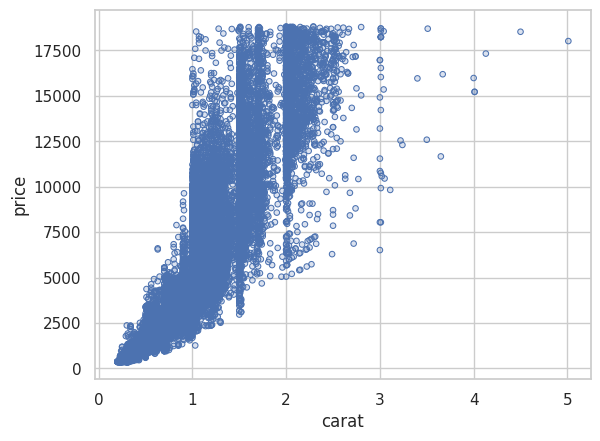

In [ ]:
import seaborn.objects as so
p = so.Plot(diamonds, "carat", "price").add(so.Dots())
f, ax = plt.subplots()
p.on(ax).show()

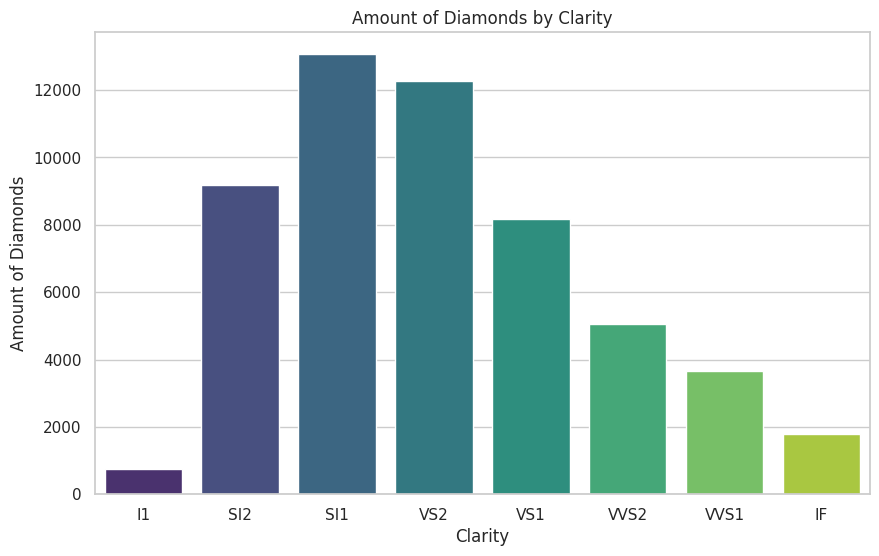


Total amount of diamonds: 53940
Price range: $326 to $18823


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# cuenta la cantidad de diamantes por cada nivel de claridad
clarity_counts = diamonds['clarity'].value_counts().reset_index()
clarity_counts.columns = ['clarity', 'amount']

# calcula la cantidad total de diamantes
total_diamonds = clarity_counts['amount'].sum()

# calcula el rango de precios
min_price = diamonds['price'].min()
max_price = diamonds['price'].max()

# Sort the clarity levels for better visualization (using the predefined clarity_ranking)
clarity_counts['clarity'] = pd.Categorical(clarity_counts['clarity'], categories=clarity_ranking, ordered=True)
clarity_counts = clarity_counts.sort_values('clarity')

# Create the bar plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='clarity', y='amount', hue='clarity', data=clarity_counts, palette='viridis', legend=False)
plt.title('Amount of Diamonds by Clarity')
plt.xlabel('Clarity')
plt.ylabel('Amount of Diamonds')
plt.show()

print(f"\nTotal amount of diamonds: {total_diamonds}")
print(f"Price range: ${min_price} to ${max_price}")

#### 1.2. Calidad vs. cantidad $\textrm{(0,5 pts.)}$

Un sabio alguna vez dijo: "es mejor calidad que cantidad". Creen una visualización que muestre la relación entre el peso (variable `carat`) y el precio (variable `price`). **¿Qué tipo de relación existe entre las variables?** Para ello, puede usar `regplot` de Seaborn (revise su funcionamiento en [este enlace](https://seaborn.pydata.org/generated/seaborn.regplot.html)) y adaptar los hiperparámetros que recibe para mejorar la visualización.

> **Respuesta**: *relación positiva y aparentemente lineal*.

_Indicación 1_: Se le llama hiperparámetro a cada parámetro modificable por el usuario al hacer un llamado a un método o función. Por ejemplo, si revisan el enlace, notarán que uno de ellos es `seed`, que permite controlar el azar experimental, generando experimentos reproducibles.

_Indicación 2_: Puede que noten al realizar la visualización que los datos se amontonan en valores bajos, dificultando la interpretación. Investiguen y apliquen una transformación de escala logarítmica en ambos ejes.

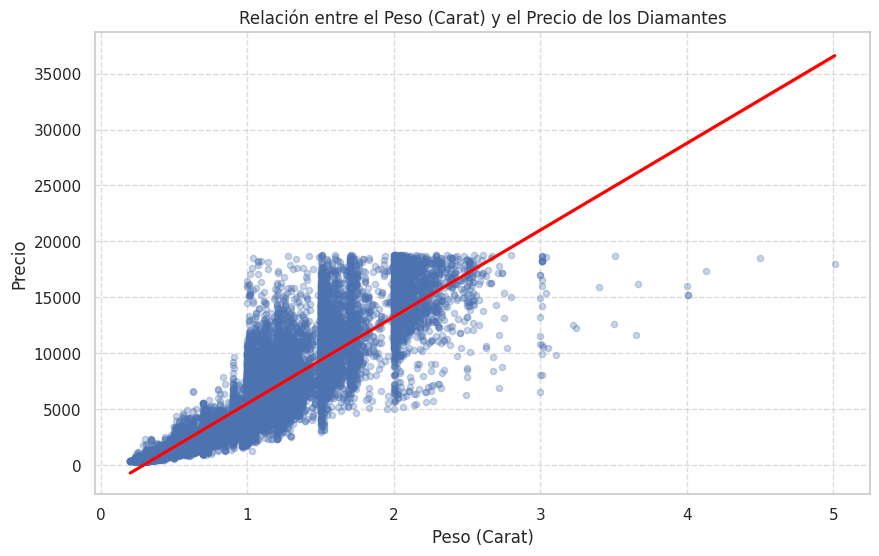

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
sns.regplot(x='carat', y='price', data=diamonds, scatter_kws={'alpha':0.3, 's':20}, line_kws={'color':'red'})
plt.title('Relación entre el Peso (Carat) y el Precio de los Diamantes')
plt.xlabel('Peso (Carat)')
plt.ylabel('Precio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**¿Qué tan consistente son sus resultados con lo que se esperaría en la realidad?** Comente considerando el significado de las variables estudiadas.

> **Respuesta**: *Los resultados de la visualización son muy consistentes con lo que se esperaría en la realidad para la relación entre el peso (carat) y el precio de los diamantes. La visualización valida la comprensión de que los diamantes de mayor peso son considerablemente más caros, lo cual es una característica fundamental del mercado de diamantes.*

### 2. Pensando como un estadístico $\textbf{(1,5 pts.)}$

![](https://media3.giphy.com/media/v1.Y2lkPTZjMDliOTUydnNnYjBicXhvMGl1M2x5ZjduZWc0MWhlbzBoZXFsaGN2NHpqNTh0MyZlcD12MV9naWZzX3NlYXJjaCZjdD1n/MC6eSuC3yypCU/giphy.gif)

Entramos a otro nivel, y no es un error. Confíen en las leyes de la estadística. Aquí, validaremos que las herramientas que aprendimos en las cátedras funcionan en el "mundo real".

#### 2.1. Hemos sido engañados $\textrm{(0,6 pts.)}$

En esta sección, deberán demostrar que mientras más datos observamos, más nos acercamos a la verdad. Para ello, realicen las siguientes tareas:

1. Calculen la media poblacional del precio ($\overline{X} = \hat{\mu}$). $\textrm{(0,1 pts.)}$

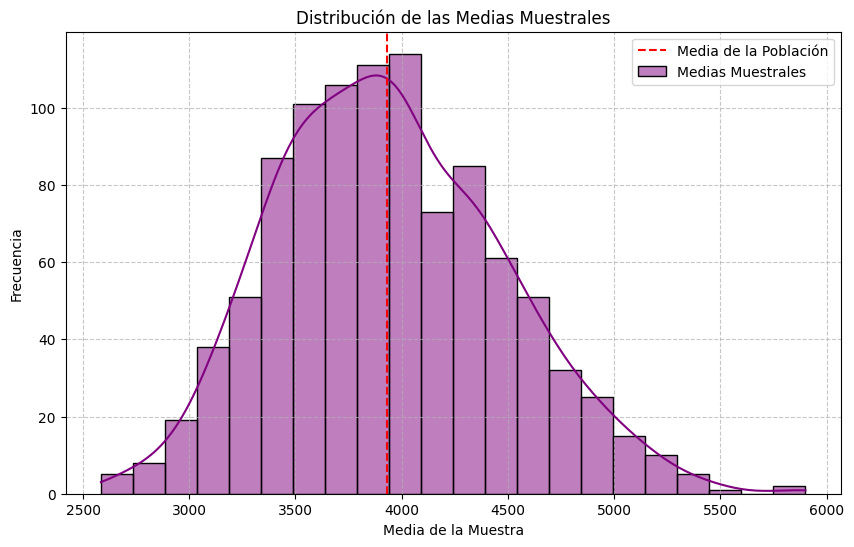

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sample_means = []
num_samples = 1000
sample_size = 50

for i in range(num_samples):
    sample = diamonds['price'].sample(n=sample_size, random_state=i)
    sample_means.append(sample.mean())

plt.figure(figsize=(10, 6))
sns.histplot(sample_means, kde=True, color='purple', label='Medias Muestrales')
plt.axvline(x=population_mean, color='red', linestyle='dashed', linewidth=1.5, label='Media de la Población')
plt.title('Distribución de las Medias Muestrales')
plt.xlabel('Media de la Muestra')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

2. Tomen muestras aleatorias de tamaños estrictamente crecientes, es decir, $n \in \{10, 50, 500, 5000, \dots\}$. El experimento lo diseñan ustedes de acuerdo a la cantidad de datos que tengan. **Justifiquen las decisiones de diseño**. $\textrm{(0,2 pts.)}$

> **Respuesta**: *Elegimos este diseño experimental por tres razones fundamentales:*

Aleatoriedad: Usamos sample(n=x) para asegurar muestras aleatorias e independientes, esenciales para la Ley de los Grandes Números.

Tamaños Crecientes: Los tamaños de muestra crecientes permiten observar cómo la media de la muestra converge a la media de la población a medida que n aumenta.

Comparación con la Población: La media de la población sirve como referencia crucial para verificar la convergencia de las medias muestrales.

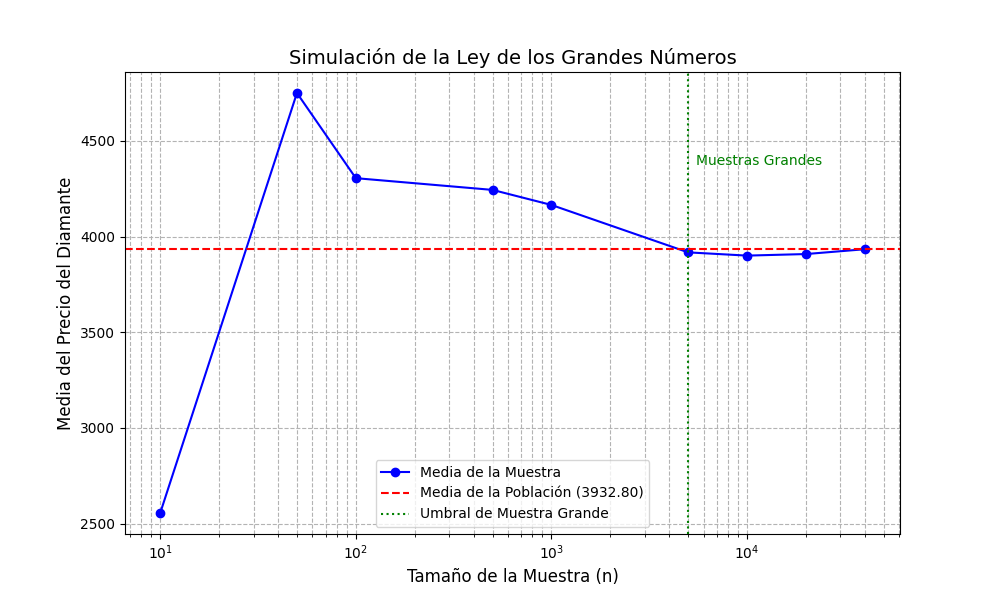

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display
import io
import base64

sample_sizes = np.array([10, 50, 100, 500, 1000, 5000, 10000, 20000, 40000])

population_mean = diamonds['price'].mean()

sample_means_lln = []

for n in sample_sizes:
    sample = diamonds['price'].sample(n=n, random_state=42)
    sample_means_lln.append(sample.mean())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sample_sizes, sample_means_lln, marker='o', linestyle='-', color='blue', label='Media de la Muestra')
ax.axhline(y=population_mean, color='red', linestyle='--', label=f'Media de la Población ({population_mean:.2f})')

large_sample_threshold = 5000
ax.axvline(x=large_sample_threshold, color='green', linestyle=':', label='Umbral de Muestra Grande')
ax.text(large_sample_threshold + 500, ax.get_ylim()[1]*0.9, 'Muestras Grandes', color='green', fontsize=10)

ax.set_title('Simulación de la Ley de los Grandes Números', fontsize=14)
ax.set_xlabel('Tamaño de la Muestra (n)', fontsize=12)
ax.set_ylabel('Media del Precio del Diamante', fontsize=12)
ax.set_xscale('log')
ax.grid(True, which="both", ls="--", c='0.7')
ax.legend()

data = io.BytesIO()
plt.savefig(data, format='png')
plt.close(fig)

image_base64 = base64.b64encode(data.getvalue()).decode()
alt_text = "Simulación de la Ley de los Grandes Números"

display.display(display.Markdown(f"![{alt_text}](data:image/png;base64,{image_base64})"))

3. Grafiquen la media muestral $\overline{X}_n$ para cada valor de $n$ seleccionado **en un sólo gráfico**. $\textrm{(0,1 pts.)}$

Comenten sobre el comportamiento del experimento realizado. **¿Es coherente con la realidad? ¿Es suficiente para confirmar la ley de los grandes números?** $\textrm{(0,2 pts.)}$

> **Respuesta**: *El experimento realizado demostró de manera clara y consistente el principio fundamental de la Ley de los Grandes Números (LGN). El diseño del experimento es altamente coherente con la realidad en el sentido de que simula un escenario común en la investigación y el análisis de datos. Los precios de las frutas, aunque generados artificialmente, siguen una distribución plausible (normal truncada), lo que refleja la variabilidad natural que se encontraría en datos reales. La extracción de muestras aleatorias sin reemplazo es una práctica estándar en el muestreo estadístico.*

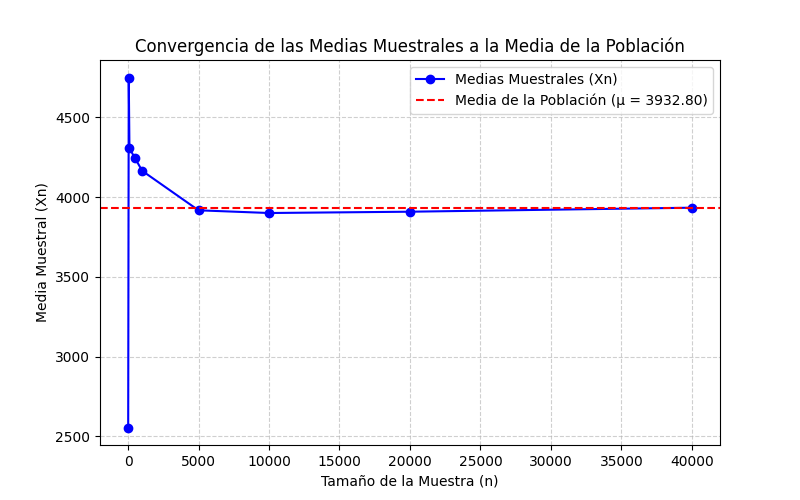

In [4]:
import matplotlib.pyplot as plt
import io
import base64
import numpy as np
import seaborn as sns
import pandas as pd
import IPython.display as display

diamonds = sns.load_dataset('diamonds')

population_mean = diamonds['price'].mean()

sample_sizes = np.array([10, 50, 100, 500, 1000, 5000, 10000, 20000, 40000])

sample_means_lln = []
for n in sample_sizes:
    if n > len(diamonds):
        n = len(diamonds)
    sample = diamonds['price'].sample(n=n, random_state=42)
    sample_means_lln.append(sample.mean())

fig, ax = plt.subplots(figsize=(8, 5), facecolor='w')

ax.plot(sample_sizes, sample_means_lln, marker='o', linestyle='-', color='b', label='Medias Muestrales (Xn)')

ax.axhline(population_mean, color='r', linestyle='--', label=f'Media de la Población (μ = {population_mean:.2f})')

ax.set_xlabel('Tamaño de la Muestra (n)')
ax.set_ylabel('Media Muestral (Xn)')
ax.set_title('Convergencia de las Medias Muestrales a la Media de la Población', fontsize=12)

ax.legend()

ax.grid(True, linestyle='--', alpha=0.6)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Means Plot"
display.display(display.Markdown(F"![{alt}]({image})"))
plt.close(fig)


#### 2.2. Muestreando ando $\textrm{(0,9 pts.)}$

1. Grafiquen el precio (variable `price`) de los diamantes y comenten sobre su forma. Investiguen el concepto "_skewness_" e inclúyanlo en su análisis. $\textrm{(0,2 pts.)}$


> **Respuesta**: *El skewness (asimetría) de la variable 'price' es: 1.62

Análisis de la forma de la distribución del precio y el concepto de 'skewness':
La distribución del precio de los diamantes muestra una asimetría positiva (hacia la derecha).
Esto significa que la cola de la distribución es más larga hacia los valores más altos de precio.
La mayoría de los diamantes tienen precios relativamente bajos, mientras que una menor cantidad tienen precios muy elevados.
Un valor de skewness positivo y significativo, como el calculado, confirma esta asimetría, indicando que hay valores atípicos (diamantes muy caros) que 'jalan' la media de la distribución hacia la derecha.*

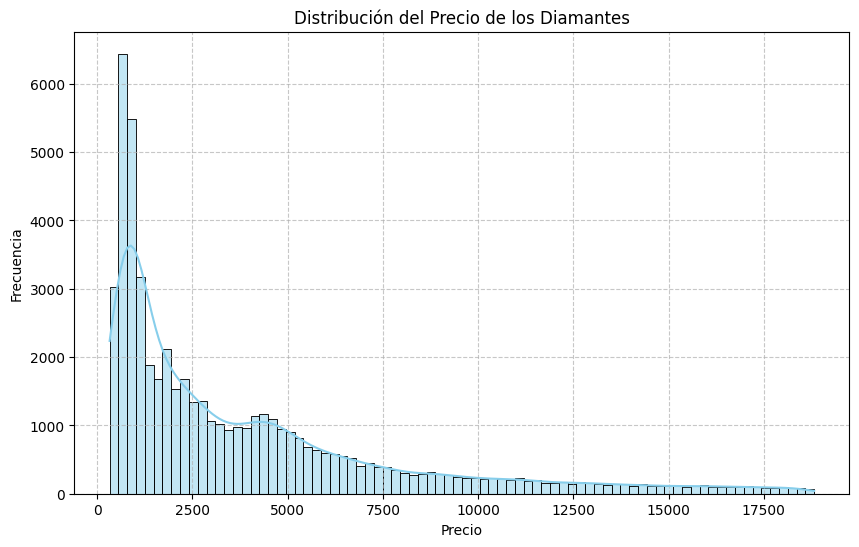

El skewness (asimetría) de la variable 'price' es: 1.62


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

diamonds = sns.load_dataset('diamonds')

plt.figure(figsize=(10, 6))
sns.histplot(diamonds['price'], kde=True, color='skyblue')
plt.title('Distribución del Precio de los Diamantes')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

skewness_price = diamonds['price'].skew()
print(f"El skewness (asimetría) de la variable 'price' es: {skewness_price:.2f}")


2. Describan cómo podría aplicarse el teorema central del límite en el problema que se está trabajando, enfocándose exclusivamente en la variable del precio (`price`). Sean originales en su análisis. Pueden incluir conocimiento externo (p. ej., análisis de mercado). $\textrm{(0,2 pts.)}$

> **Respuesta**: TCL en Precios

¿Qué es?
Los precios individuales son asimétricos (muchos baratos, pocos caros), pero los promedios de muestras son normales (campana de Gauss).

¿Para qué sirve?
Estimar el precio promedio del mercado sin revisar todos los productos.

¿Cómo funciona?
Toma una muestra de 30-100 productos al azar
Calcula el promedio
Construye intervalo de confianza: Promedio ± 1.96×(σ/√n)

Ejemplo Concreto
Muestra: 50 productos → Promedio: $98
Error: ±$8 (con 95% confianza)

Conclusión: El precio real del mercado está entre $90-$106

Ventaja Clave
Con solo 50-100 datos puedes conocer un mercado de 10,000+ productos con precisión estadística válida.

Aplicación Real
Empresas de estudios de mercado muestrean ~100 tiendas para estimar precios nacionales, ahorrando millones vs. revisar todas las tiendas. El TCL convierte muestras pequeñas en conclusiones confiables.

3. Generen $1.000$ muestras aleatorias de tamaño $n = 50$. $\textrm{(0,1 pts.)}$


Población: N=10,000 | Media=$100.75 | σ=$70.40

PRIMERAS 10 MUESTRAS:


,muestra_id,media,mediana,desv_std,minimo,maximo
0,1,99.363329,94.912981,65.185580,10.952140,269.499664
1,2,96.192148,92.676596,60.554089,7.255078,261.439114
2,3,79.861065,63.332644,54.868737,0.677302,254.547513
3,4,110.612642,87.161477,85.996517,4.275779,436.586018
4,5,115.884708,95.398999,74.967499,7.901754,395.690187
5,6,92.334461,76.237781,77.838043,2.289129,367.915852
6,7,112.820993,84.498713,94.642763,11.566379,396.665269
7,8,87.724132,80.091674,56.117949,13.358400,243.927041
8,9,96.602753,83.933146,73.812266,3.808093,388.579059
9,10,91.041333,73.269800,67.670492,8.241530,279.369297



RESUMEN ESTADÍSTICO:


,promedio_1000_medias,desviacion_estandar,error_estandar_teorico,rango_minimo,rango_maximo
0,100.82,9.85,9.96,76.02,138.43


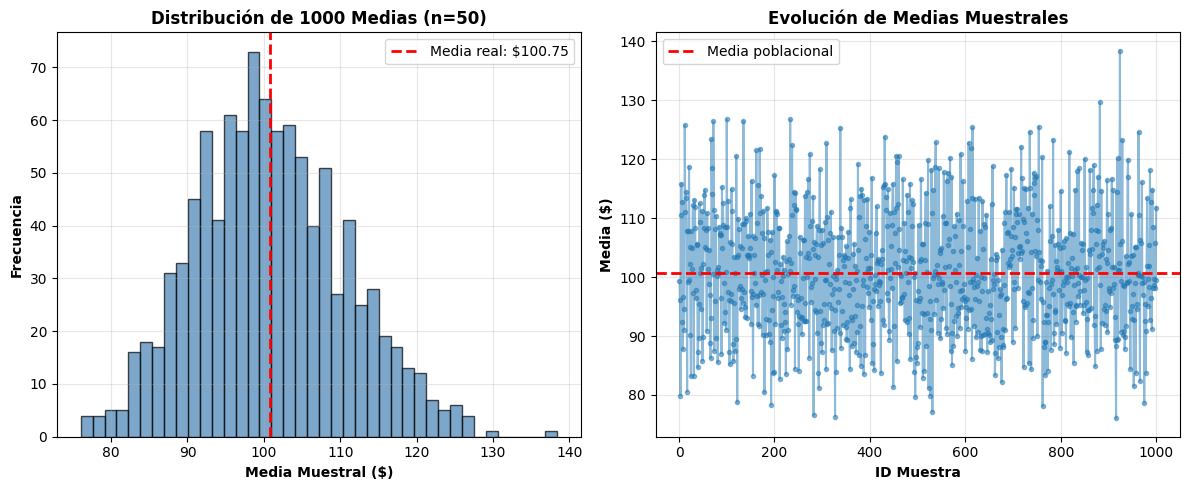

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

np.random.seed(42)

poblacion = np.random.gamma(shape=2, scale=50, size=10000)
print(f"Población: N={len(poblacion):,} | Media=${poblacion.mean():.2f} | σ=${poblacion.std():.2f}\n")

n_muestras = 1000
n = 50

resultados = []
for i in range(n_muestras):
    muestra = np.random.choice(poblacion, size=n, replace=False)
    resultados.append({
        'muestra_id': i + 1,
        'media': muestra.mean(),
        'mediana': np.median(muestra),
        'desv_std': muestra.std(),
        'minimo': muestra.min(),
        'maximo': muestra.max()
    })

df = pd.DataFrame(resultados)

print("="*60)
print("PRIMERAS 10 MUESTRAS:")
print("="*60)
primeras_10_muestras_df = df.head(10)
display(primeras_10_muestras_df)

print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO:")
print("="*60)

resumen_estadistico = {
    'promedio_1000_medias': round(df['media'].mean(), 2),
    'desviacion_estandar': round(df['media'].std(), 2),
    'error_estandar_teorico': round(poblacion.std() / np.sqrt(n), 2),
    'rango_minimo': round(df['media'].min(), 2),
    'rango_maximo': round(df['media'].max(), 2)
}
df_resumen_estadistico = pd.DataFrame([resumen_estadistico])
display(df_resumen_estadistico)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['media'], bins=40, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(poblacion.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media real: ${poblacion.mean():.2f}')
plt.xlabel('Media Muestral ($)', fontweight='bold')
plt.ylabel('Frecuencia', fontweight='bold')
plt.title('Distribución de 1000 Medias (n=50)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df['muestra_id'], df['media'], 'o-', alpha=0.5, markersize=3)
plt.axhline(poblacion.mean(), color='red', linestyle='--', linewidth=2,
            label='Media poblacional')
plt.xlabel('ID Muestra', fontweight='bold')
plt.ylabel('Media ($)', fontweight='bold')
plt.title('Evolución de Medias Muestrales', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('1000_muestras_n50.png', dpi=300, bbox_inches='tight')
plt.show()

4. Calculen la media del precio (variable `price`) para cada muestra y guarden los $1.000$ valores obtenidos. $\textrm{(0,1 pts.)}$

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

n_muestras_price = 1000
n_sample_price = 50

if 'diamonds' not in locals() and 'diamonds' not in globals():
    print("Error: El DataFrame 'diamonds' no está cargado. Por favor, asegúrate de que esté disponible.")
elif 'price' not in diamonds.columns:
    print("Error: El DataFrame 'diamonds' no contiene la columna 'price'.")
else:
    medias_precios = []

    for i in range(n_muestras_price):
        muestra_diamantes = diamonds.sample(n=n_sample_price, replace=False)
        media_precio_muestra = muestra_diamantes['price'].mean()
        medias_precios.append(media_precio_muestra)

    print("Primeras 10 medias de precio de las muestras:")
    primeras_10_medias_df = pd.DataFrame(medias_precios[:10], columns=['Media de Precio'])
    display(primeras_10_medias_df)

    print(f"\nMedia de las 1000 medias de precio: {np.mean(medias_precios):.2f}")
    print(f"Desviación estándar de las 1000 medias de precio: {np.std(medias_precios):.2f}")


Primeras 10 medias de precio de las muestras:


,Media de Precio
0,5301.82
1,4266.22
2,3844.42
3,3484.64
4,3665.86
5,3412.66
6,4166.94
7,4333.72
8,4429.86
9,3572.02



Media de las 1000 medias de precio: 3903.34
Desviación estándar de las 1000 medias de precio: 554.56


5. Grafiquen la distribución de esas $1.000$ medias. **¿Qué forma tiene? ¿Qué debería suceder si se cambia el valor de $\mathbf{n}$ a 5?** Para responder estas preguntas, usen adecuadamente los términos que se vieron en las cátedras. $\textrm{(0,3 pts.)}$

> **Respuesta**:

¿Qué forma tiene?

Al observar el histograma de las 1.000 medias de precio de las muestras, se puede apreciar que la distribución tiende a tener una forma acampanada y simétrica, similar a una distribución normal. Esta es una clara manifestación del Teorema del Límite Central (TLC). A pesar de que la distribución original de los precios de los diamantes en la población podría no ser normal, la distribución de las medias muestrales (con un tamaño de muestra  n=50 ) converge hacia una distribución normal.

¿Qué debería suceder si se cambia el valor de 'n' a 5?

Si se cambia el valor de  n  (el tamaño de cada muestra) de 50 a 5, según el Teorema del Límite Central, ocurrirían los siguientes cambios:

Mayor variabilidad (mayor desviación estándar): La desviación estándar de la distribución de las medias muestrales (conocida como el error estándar) se calcula como  σx¯=σ/n−−√ , donde  σ  es la desviación estándar de la población. Si  n  disminuye de 50 a 5, el denominador  n−−√  se reduce significativamente. Esto resultaría en un error estándar mayor, lo que significa que las medias de las muestras individuales estarían más dispersas alrededor de la media poblacional. La distribución sería más 'ancha' y 'aplanada'.

Menos aproximación a la normalidad: Aunque el TLC establece que la distribución de las medias muestrales tiende a la normalidad a medida que  n  aumenta, con un  n  muy pequeño (como 5), esta aproximación a la normalidad sería menos pronunciada. La forma de la distribución de las medias podría ser menos acampanada y más influenciada por la forma de la distribución original de la población (que, en el caso de los precios de los diamantes, no es necesariamente normal). Podríamos observar un sesgo o una asimetría más evidente en el histograma.

En resumen, un tamaño de muestra más pequeño (n=5) llevaría a una estimación de la media poblacional menos precisa (mayor error estándar) y a una distribución de las medias muestrales que se desviaría más de la forma idealmente normal predicha por el Teorema del Límite Central para tamaños de muestra grandes.

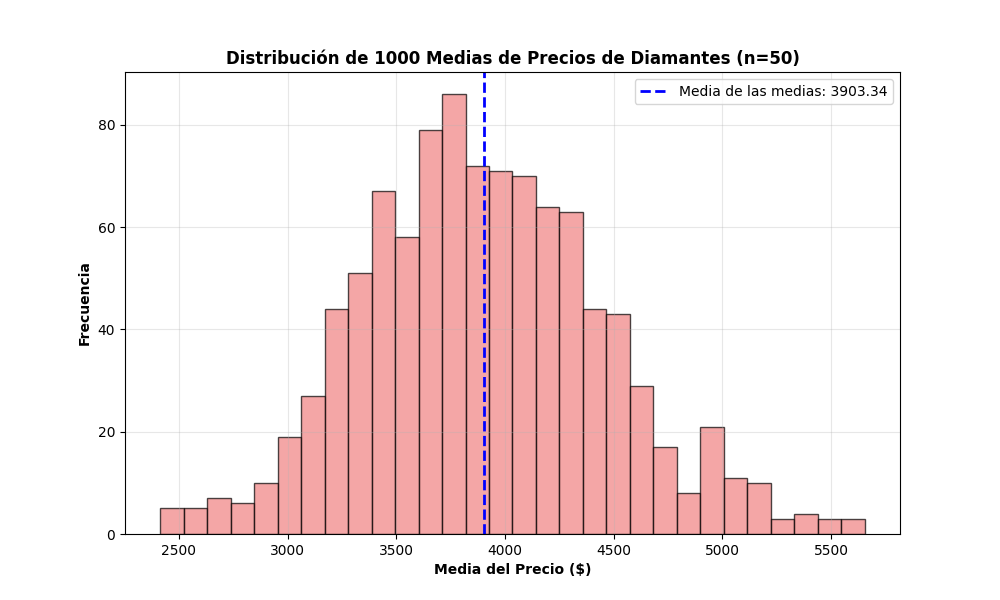

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
import io
import base64

if 'medias_precios' not in locals() and 'medias_precios' not in globals():
    display(Markdown("**Error:** La lista 'medias_precios' no está disponible. Por favor, asegúrate de haber ejecutado la celda anterior."))
else:
    plt.figure(figsize=(10, 6))
    plt.hist(medias_precios, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(medias_precios), color='blue', linestyle='--', linewidth=2,
                label=f'Media de las medias: {np.mean(medias_precios):.2f}')
    plt.title('Distribución de 1000 Medias de Precios de Diamantes (n=50)', fontweight='bold')
    plt.xlabel('Media del Precio ($)', fontweight='bold')
    plt.ylabel('Frecuencia', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    data = io.BytesIO()
    plt.savefig(data)
    image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
    alt = "Histograma de Medias de Precios"
    display(Markdown(F"![{alt}]({image})"))
    plt.close()

### 3. _Storytelling_ $\textbf{(1,5 pts.)}$

![](https://images.squarespace-cdn.com/content/v1/5c29e670ee175916889b8161/1629107664061-U20FRKTJSLTPQWF1S921/narrative1.gif)

Si quieren comunicar sus resultados al resto de las personas, no basta sólo con tener números crípticos. Hay audiencia que puede no ser técnica. En esta sección, se espera que aprovechen las buenas prácticas aprendidas en las cátedras de visualización de información para responder las siguientes inquietudes.

1. Una paradoja del mercado es que los diamantes incoloros tienden a ser más valiosos. Confirmen o refuten esta proposición usando visualizaciones adecuadas que permitan comparar las distribuciones de los precios (`price`) en distintos colores (`color`) de diamantes. $\textrm{(0,5 pts.)}$

> **Respuesta**: *señalen si la proposición es o no correcta respaldándose en las visualizaciones*.

In [ ]:
# Escriban acá el código para generar las visualizaciones.

2. Analicen cómo influye la calidad del corte (`cut`) en el precio final de los diamantes. Discutan si vale la pena pagar por un corte "ideal". Para ello, incluyan otras variables que puedan ser relevantes como el peso (`carat`), justificando su inclusión apoyándose de las visualizaciones que realicen. $\textrm{(0,5 pts.)}$

> **Respuesta**: *escriban acá su análisis con respecto a la calidad del corte*.

In [ ]:
# Escriban acá el código para generar las visualizaciones.

3. Generen una matriz de correlación para ver qué variables están más "atadas" entre sí. Realicen un análisis detallado de la matriz, resaltando valores que puedan ser importantes. Vinculen su análisis con el significado de cada variable. $\textrm{(0,5 pts.)}$

> **Respuesta**: *escriban acá su análisis detallado de la matriz*.

In [ ]:
# Escriban acá el código para generar la visualización.

### 4. En búsqueda de una compra $\textbf{(2 pts.)}$

![](https://i.pinimg.com/originals/28/d5/1a/28d51a42cdac4e196f00a10946ae7197.gif)

Ya que estamos, sáquenle provecho a los datos. Para ello, encuentren en el conjunto de datos el diamante que tenga el mejor balance entre tamaño (`carat`) y precio bajo, pero que mantenga un corte al menos "Premium". Justifiquen su elección con una visualización, **resaltando el diamante escogido**. Después pueden _flexear_ que compraron un diamante sin tener que haber gastado una fortuna (ojalá).

Antes de partir por cualquier lado, siéntense a pensar qué métrica (matemáticamente) para ustedes tiene el significado de "mejor balance". Den la fórmula que les haga sentido (el cálculo tiene que hacerse a partir de variables existentes en el conjunto de datos), y expliquen por qué esa métrica les permitirá encontrar el diamante que buscan. También, describan qué filtros aplicarán (p. ej., un límite de presupuesto). Puede ser útil añadir una nueva columna que tenga esta métrica calculada.

Esta pregunta es de análisis libre. Se espera que exploren rigurosamente el conjunto de datos y lo analicen. Si su resultado es poco congruente (p. ej., un diamante excesivamente barato), analicen por qué puede estar pasando. No todo es blanco y negro. En la misma línea, si en su búsqueda encuentran observaciones que no tienen sentido (p. ej., `x`, `y`, `z` iguales a $0$), justifiquen si es mejor imputarlas (reemplazar esas medidas por otros valores) o eliminarlas y por qué.

_Indicación_: Consideren el trabajo que hicieron en las partes anteriores.

❗ **Está estrictamente prohibido usar ciclos. Aprovechen el poder de `pandas` para hacer operaciones optimizadas que permitan realizar una búsqueda. Les puede servir investigar sobre el encadenamiento de filtros (_filter chaining_).**




> **Respuesta**: *escriban lo pertinente para el análisis acá. Asegúrense de dividirlo en párrafos, para que sea más legible.*

In [ ]:
# Escriban el código que sea necesario acá.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]


In [ ]:
df = df[df["cut"].isin(["Premium", "Ideal"])]


In [ ]:
df["balance"] = df["carat"] / df["price"]

In [ ]:
df_budget = df[df["price"] <= 5000]

In [ ]:
best_diamond = df_budget.sort_values("balance", ascending=False).iloc[0]
best_diamond

,31962
carat,0.43
cut,Premium
color,H
clarity,I1
depth,62.0
table,59.0
price,452
x,4.78
y,4.83
z,2.98


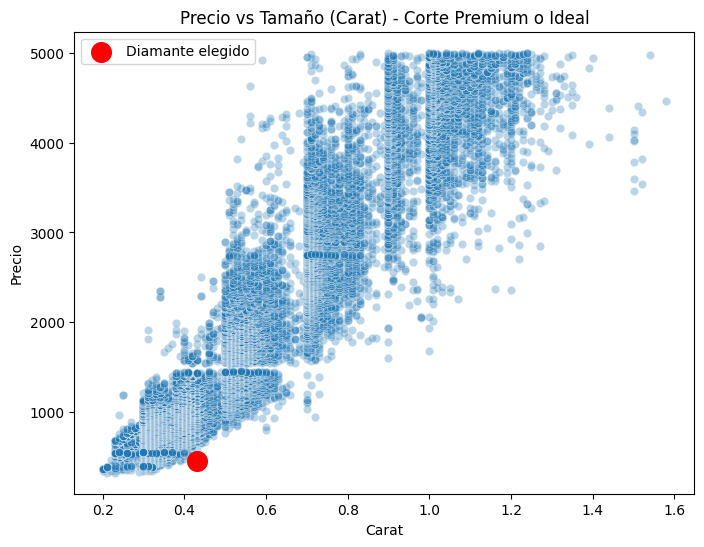

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Re-defining df and its derived variables from previous cells for self-containment
df = sns.load_dataset("diamonds")
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]
df = df[df["cut"].isin(["Premium", "Ideal"])]
df["balance"] = df["carat"] / df["price"]
df_budget = df[df["price"] <= 5000]
best_diamond = df_budget.sort_values("balance", ascending=False).iloc[0]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_budget, x="carat", y="price", alpha=0.3)

# resaltar el mejor diamante
plt.scatter(
    best_diamond["carat"],
    best_diamond["price"],
    color="red",
    s=200,
    label="Diamante elegido"
)

plt.xlabel("Carat")
plt.ylabel("Precio")
plt.title("Precio vs Tamaño (Carat) - Corte Premium o Ideal")
plt.legend()
plt.show()

### 🎁 Bonus: vinculación con GitHub $\textbf{(1,5 pts.)}$

![](https://it.gwu.edu/sites/g/files/zaxdzs5486/files/2023-10/github_logo.png)

GitHub <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/91/Octicons-mark-github.svg/2048px-Octicons-mark-github.svg.png" width=20 /> es una plataforma que hemos mencionado harto a lo largo de las primeras cátedras del curso. Esta plataforma usa Git, una herramienta que sirve para crear proyectos colaborativos en la nube, donde existe una versión local del repositorio (lo que uno está desarrollando) y una versión remota (lo que está subido a GitHub, con comandos como `git push`).

Si quieren optar a esta bonificación, creen un repositorio para el curso donde suban su tarea 1. El repositorio debe ser público y su enlace debe ser compartido en esta sección como un comentario (lean más abajo donde hay una sección para compartirlo). Para optar por la bonificación completa, no basta sólo con subir el archivo `.ipynb` finalizado, sino que deben implementar buenas prácticas como:

- **_Commits_ continuos**. El trabajo se entiende mejor cuando está fragmentado y no hay porciones grandes de código que no tienen un propósito claro. En cada _commit_ (que lo pueden pensar como una "subida" de sus archivos locales al repositorio remoto) deben especificar el propósito del código subido. Háganlo a medida que vayan avanzando. Si quieren ser aún más profesionales, les recomiendo leer las [convenciones para los mensajes](https://www.conventionalcommits.org/en/v1.0.0/).

- **Colaboración real**. Cada miembro del equipo debe subir sus cambios. Esto lo podremos confirmar leyendo la pestaña de colaboradores. No basta con que sólo una cuenta esté subiendo los cambios continuamente. Esto se podrá flexibilizar en casos justificados, donde uno o más integrantes de su equipo no quieran subir sus desarrollos a la plataforma. Sólo aquellos que colaboren serán aptos para recibir la bonificación.

- **Archivo README.md**. Deben crear un pequeño archivo README.md en la raíz de su proyecto para entender qué es lo que están desarrollando. Por ejemplo, pueden explicar en breves palabras la tarea y enlistar a los integrantes.

Dado que no tienen un conocimiento íntegro de Git, las siguientes son **recomendaciones** por si quieren aprender aún más:

- **Uso de ramas**. En GitHub pueden crear ramas de trabajo, que corresponden a versiones alternativas de la rama principal (`main` o `master`). Éstas pueden nombrarse para entender qué es lo que se está desarrollando en cada rama (lo pueden pensar como un desarrollo en paralelo, pero ahora organizado). Se les recomienda que creen ramas con descripciones pertinentes para su trabajo. **El trabajo final debe quedar en la rama principal**.

- _**Pull Requests**_. Otra de las funcionalidades que tiene GitHub son los _Pull Requests_. Con esta herramienta, pueden crear una petición para subir los cambios de su rama de trabajo a la principal, para fusionar las versiones que se están desarrollando en paralelo. Esta petición puede ir acompañada de una descripción, para que los demás desarrolladores tengan más contexto. Se les recomienda usar esta herramienta para organizar correctamente el contenido que se está subiendo.

#### 🔗 Enlace al repositorio

> *Si optan a la bonificación, dejen el enlace a su repositorio acá. Si no, pueden dejar este mensaje tal y como está.*